# Agents: Some key concepts
---

### What is an Agent?

In context of Large Language Models (`LLMs`), an agent is an autonomous or semi-autonomous system that can take actions on behalf of the user in a given environment, state, and make decisions or take actions that can accomplish certain tasks. A more detailed explanation of agents would be systems powered by `LLMs`, or `LLMs` themselves that have access to a certain user environment, external sources (such as data) that they can use to accomplish user tasks by efficiently breaking the request into smaller components. An agent can perform these tasks using different components given below:

### Tools
Tools are simple functions (can be python functions) that agents use to interact with `APIs` or external data sources. Tools can be of various kinds but can be divided into two portions:

- `Built-in tools`: Several Agentic frameworks that help you build agents provide tools that are already implemented that you can use through your agent such as:
    1. Web search tools to retrieve information from the web (such as `DuckDuckGo`, `Bing Search`, `Wikipedia API`).
    1. Database tools such as `SQL Database connector` to execute SQL queries against relational databases.
    1. Different frameworks provide a host of different built-in tools. For example, view some built-in tools offered by `LangChain` [here](https://python.langchain.com/docs/concepts/tools/)

- `Custom tools`: You can build your own custom tools that perform various actions by interacting with your choice of custom/proprietary `APIs`. View some of these examples below:
    1. **Document parsing**: Extract and analyze text from PDF documents, create summaries of long documents, etc. 
    1. **Task management**: Create and assign tasks in project management systems for your specific use cases and customer stories.
    1. **Budget analyzer**: Categorize and analyze spending patterns across your company infrastructure using custom `APIs`.
    1. **Code analyzer**: Review code for bugs or improvements using your own fine-tuned model.

**Note**: Writing tools are simple as writing functions. You can write tools using different approaches via different frameworks. In this lab, we will go over how we can write tools in `LangGraph`.

### Workflows
Workflows are how agents can use a predefined sequence of operations that define how an agent can process information and take action. For example, a single agent can have access to multiple tools and be prompted to perform those actions either in a 

1. `sequential` manner (executing tools one by one), 
1. `branching`, where the agent dynamically determines which tool to call based on the step it took previously, 
1. `Cyclic`, where the agent can perform the same set of steps with a human in the loop to review and iterate on the new results or -
1. It can be a combination of various workflows and agents interacting all together.

### Persistence/Memory
Imagine if you had an agent powering your chatbot serving thousands of users. In that case, it becomes important to retain the memory and the state of the agent with specific user interactions. This is essential for:
1. Maintaining conversation context, 
1. Resuming interrupted operations
1. Tracking process across multiple user sessions.

### Human-in-the-loop (`HITL`)
Agents act autonomously and need to be evaluated. This requires iterative testing and a human, who can check the steps that an agent takes and makes sure that the agent is performing and executing the right steps and tools. For this, it is important to have a human-in-the-loop. 
- This workflow integrates a human input into automated processes, allowing for decisions.
- Useful in LLM-based applications to check for accuracy
- Examples of these are:
    1. **Reviewing tool calls**: Humans can review, edit or approve which tools to call by the agent.
    1. **Validating `LLM` outputs**: Humans can review, edit or approve the outputs generated by `LLMs`.
    1. **Providing context**: You can have the `agent` or `LLM` return control to the user. This means that the agent will pause and ask the human or user for validation before executing an action. (For example, asking for more information, or clarifying steps to take)

### Prompting
Prompting is a technique to control and provide instructions to how an `LLM` can process user inputs and generate responses. In Agentic systems, prompts are essential for:
1. **Defining the agent's role or capabilities**: Your agent solution might have several agents working together. In that case, having separate instructions and guidance for agents can be provided through prompts.
1. **Structuring the agent's thinking process**: Your agent's thinking process is defined by the instructions that you provide in the prompt. This includes if you want your agent to execute certain tools before the others for example.
    
**Note**: Prompt engineering is a separate topic and more information on this can be found [here](https://aws.amazon.com/what-is/prompt-engineering/). Prompt templates will be different from model-to-model to get the best performance for your agent use case.

### State management
State management in agents refer to tracking and updating the variables that the agent uses based on the conversation history, task progress, available resources and user preferences.

## Agent frameworks
There are several Agent frameworks that can help us build stateful, persistent agents. These frameworks are either open-source (Such as LangGraph, LangChain, [CrewAI](https://www.crewai.com/)) or AWS-offered, such as [Agents on Amazon Bedrock](https://aws.amazon.com/bedrock/agents/).

# Build a Basic Chatbot
---

In this example, we will create a simple chatbot using `LangGraph`. This chatbot will directly respond to user messages. It will introduce the core concepts of building with `LangGraph`.

First, create a state graph. A `StateGraph` object defines the structure of the chatbot as a "state machine". We will add `nodes` to this to represent the `llm` and `functions` our chatbot can call and `edges` to specify how the bot should transition between these functions.

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

# import langgraph libraries
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    # messages have the type "list". The add_messages function
    # in the annotation defines how this state key should be updated.
    # In this case, it appends the messages to the list rather than
    # overriding them
    messages: Annotated[list, add_messages]

# Now, we build our graph
graph_builder = StateGraph(State)

This graph can now handle two tasks:

1. Each `node` can now receive the current `State` as input and output an update to the state.

1. Updates to the `messages` will be appended to the existing list rather than overwriting it.

### Key Concepts
---

When defining a graph, we first define the `State` of the graph. The state of the graph refers to the graph's schema and `reducer functions`. This reducer function handles the state updates. In this example, the `State` is a `TypedDict` with one key: `messages`. We use the `add_messages` reducer function to append new messages to the list instead of overwriting it. Keys without a reducer annotation will overwrite the previous values. 

1. `Nodes`: These are simple python functions and each node operates on States

1. `Edges`: The edges simply connect the notes and this can include normal edges and conditional edges.

***In short: nodes do the work. edges tell what to do next.***

In [2]:
BEDROCK_MODEL_ID: str = 'anthropic.claude-3-5-haiku-20241022-v1:0'

In [3]:
from langchain_community.chat_models.bedrock import BedrockChat

llm = BedrockChat(
    model_id=BEDROCK_MODEL_ID,
    model_kwargs={"temperature": 0.1},
)

/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_52425/3737788696.py:3: LangChainDeprecationWarning: The class `BedrockChat` was deprecated in LangChain 0.0.34 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-aws package and should be used instead. To use it run `pip install -U :class:`~langchain-aws` and import as `from :class:`~langchain_aws import ChatBedrock``.
  llm = BedrockChat(


In [4]:
# create a function that creates the chatbot
def chatbot(state: State):
    # this invokes the llm and adds the messages to the list of messages
    # in the state
    return{"messages": [llm.invoke(state['messages'])]}

In [5]:
# let's add the node to the graph
graph_builder.add_node("chatbot", chatbot)

In [6]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

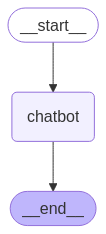

In [7]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Error displaying graph: ", e)

In [8]:
# Now, let's run the chatbot application
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

In [9]:
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # FALLBACK IF THE INPUT IS NOT AVAILABLE
        user_input = "I am having a problem with my EC2 instance, what to do?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: AWS (Amazon Web Services) is a comprehensive cloud computing platform provided by Amazon. Here are key details about AWS:

1. Cloud Services
- Offers a wide range of cloud computing services
- Provides infrastructure, storage, databases, networking, analytics, machine learning, and more
- Allows businesses to run applications and host services online

2. Key Features
- Scalable infrastructure
- Pay-as-you-go pricing model
- Global network of data centers
- High reliability and security
- Flexible computing resources

3. Popular Services
- Amazon EC2 (Elastic Compute Cloud)
- Amazon S3 (Simple Storage Service)
- Amazon RDS (Relational Database Service)
- AWS Lambda
- Amazon CloudFront
- Amazon DynamoDB

4. Benefits
- Cost-effective
- Flexible and adaptable
- Supports global business operations
- Reduces need for on-premises infrastructure
- Provides advanced security features

5. Use Cases
- Web hosting
- Mobile and web application development
- Big data processing
- Machine 

### Enhance the chatbot with tools
---

In this section of the notebook, we will have the chatbot integrate with a web search tool. For web search, we will use Tavily. Set your tavily API key here.

In [10]:
import os
os.environ['TAVILY_API_KEY'] = ''

In [11]:
# Now, we will define the tool
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]
tool.invoke("What is a 'node' in LangGraph?")

[{'url': 'https://blog.langchain.dev/langgraph/',
  'content': 'TL;DR: LangGraph is module built on top of LangChain to better enable creation of cyclical graphs, often needed for agent runtimes. This state is updated by nodes in the graph, which return operations to attributes of this state (in the form of a key-value store). After adding nodes, you can then add edges to create the graph. An example of this may be in the basic agent runtime, where we always want the model to be called after we call a tool. graph.add_edge("tools", "model") The state of this graph by default contains concepts that should be familiar to you if you\'ve used LangChain agents: input, chat_history, intermediate_steps (and agent_outcome to represent the most recent agent outcome)'},
 {'url': 'https://medium.com/@cplog/introduction-to-langgraph-a-beginners-guide-14f9be027141',
  'content': 'In this article, we’ll introduce LangGraph, walk you through its basic concepts, and share some insights and common point

#### Next, create the graph
---

The steps are the same as above, but now we will use `bind_tools` on our LLM.

In [12]:
from typing import Annotated
from langchain_aws import ChatBedrockConverse
class newState(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(newState)

In [13]:
# currently, chat bedrock converse works with tools, not chat bedrock
llm = ChatBedrockConverse(
    model_id=BEDROCK_MODEL_ID,
    temperature = 0.1,
)

In [14]:
llm_with_tools = llm.bind_tools(tools)

In [15]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state['messages'])]}

In [16]:
graph_builder.add_node("chatbot", chatbot)

## `BasicToolNode` Implementation
---

Next, to actually run the tools if they were called, we will create the `BasicToolNode` that will check the most recent message in the state and calls if the message contains `tool_calls`.

In [17]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage"""
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}
    
    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}


tool_node = BasicToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

In [18]:
# Now, with the tool node added to the graph builder, we can add edges that can route the control flow from one node to the next.
# We can also add conditional edges that usually contain "if" statements.
def route_tools(
    state: State,
):
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [19]:
# The `tools_condition` function returns "tools" if the chatbot asks to use a tool, and "END" if
# it is fine directly responding. This conditional routing defines the main agent loop.
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node
    # It defaults to the identity function, but if you
    # want to use a node named something else apart from "tools",
    # You can update the value of the dictionary to something else
    # e.g., "tools": "my_tools"
    {"tools": "tools", END: END},
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

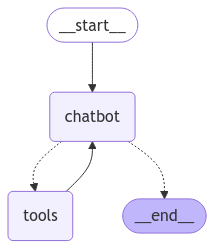

In [20]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [21]:
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: [{'type': 'text', 'text': 'Let me search for some comprehensive information about AWS.'}, {'type': 'tool_use', 'name': 'tavily_search_results_json', 'input': {'query': 'AWS Amazon Web Services definition cloud computing'}, 'id': 'tooluse_90qvnGOrTg2XVMncAbXajQ'}]
Assistant: [{"url": "https://www.techtarget.com/searchaws/definition/Amazon-Web-Services", "content": "AWS (Amazon Web Services) is a comprehensive, evolving cloud computing platform provided by Amazon. AWS was the first developer of cloud-based services, and, as a result, has a large inventory of offerings and customer base. AWS includes various tools and services designed to help users migrate applications, databases, servers and data onto its public cloud. Once applications, databases, servers and data are migrated to the cloud or a hybrid environment, tools like AWS Outposts deliver AWS services and infrastructure across multiple environments. AWS provides a range of services for cloud security, including AWS Id

### Full code provided below
---

In this code, we use the `ToolNode` and the `tools_condition` that are already prebuilt.

In [22]:
from typing import Annotated

# next, import langchain and other libraries
from langchain_aws import ChatBedrockConverse
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict

# import langgraph libraries
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
# now we import the prebuilt tool node and tools condition here
from langgraph.prebuilt import ToolNode, tools_condition

# Now we will create the state
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)
tool = TavilySearchResults(max_results=2)
tools = [tool]
llm = ChatBedrockConverse(model_id=BEDROCK_MODEL_ID, temperature=0.1, max_tokens=100)
llm_with_tools = llm.bind_tools(tools)

# Next create our first node, which is the chatbot node
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state)]}

# Next, add the chatbot node to the graph
graph_builder.add_node("chatbot", chatbot)

# Next, add the tool node
tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

# next, add the conditional edges
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

# Anytime a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.set_entry_point("chatbot")
graph = graph_builder.compile()

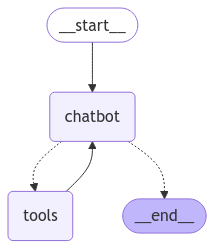

In [23]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass